In [2]:
import subprocess
import sys

def pip_install(*args, quiet=True):
    cmd = [sys.executable, "-m", "pip", "install"]
    if quiet:
        cmd.append("-q")
    cmd.extend(args)
    subprocess.check_call(cmd)

# Core packages
core_packages = [
    ["--upgrade", "huggingface_hub"],
    ["--upgrade", "transformers"],
    ["--upgrade", "accelerate"],
    ["--upgrade", "bitsandbytes"],
    ["--upgrade", "sentencepiece"],
    ["openpyxl"],
    ["pandas"],
    ["numpy"],
    ["scikit-learn"],
    ["matplotlib"],
    ["rouge-score"],
    ["nltk"],
]

for pkg_args in core_packages:
    pip_install(*pkg_args)

# Uninstall old Unsloth packages
subprocess.run(
    [sys.executable, "-m", "pip", "uninstall", "unsloth", "unsloth-zoo", "-y", "-q"],
    check=False
)

# Install Unsloth-related packages
unsloth_packages = [
    "datasets>=3.4.1,<4.4.0",
    "trl>=0.18.2,<=0.24.0",
    "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git",
]

for pkg in unsloth_packages:
    pip_install(pkg)

In [1]:

import os
from huggingface_hub import login

hf_token = os.environ.get("HF_TOKEN")
if hf_token:
    login(token=hf_token)
    print("Logged in via HF_TOKEN environment variable")
else:
    login()
    print("Logged in interactively")


Logged in interactively


In [2]:
import pandas as pd
import numpy as np
import requests
import os

GITHUB_USER = "SiddharthTiwarids23"
GITHUB_REPO = "Conversation-coaching-experiment"
BRANCH      = "main"
BASE_URL    = f"https://raw.githubusercontent.com/{GITHUB_USER}/{GITHUB_REPO}/{BRANCH}"

def download_file(filename):
    if os.path.exists(filename):
        print(f"  {filename} already exists (persistent storage), skipping download")
        return
    url = f"{BASE_URL}/{filename}"
    r = requests.get(url)
    if r.status_code == 200:
        with open(filename, "wb") as f:
            f.write(r.content)
        print(f"  {filename} ({len(r.content)/1024:.1f} KB)")
    else:
        print(f"  FAILED: {filename} -- HTTP {r.status_code}")


download_file("300_dialog.xlsx")
download_file("300_info.xlsx")

df_dialog = pd.read_excel("300_dialog.xlsx")
df_info   = pd.read_excel("300_info.xlsx")

df_dialog = df_dialog.rename(columns={
    'B2':'dialogue_id','B4':'role','Turn':'turn','Unit':'utterance',
    'er_label_1':'persuader_label_1','er_label_2':'persuader_label_2',
    'ee_label_1':'persuadee_label_1','ee_label_2':'persuadee_label_2',
    'neg':'sentiment_neg','neu':'sentiment_neu','pos':'sentiment_pos',
})
df_dialog = df_dialog.drop(columns=['Unnamed: 0'], errors='ignore')

df_info = df_info.rename(columns={
    'B2':'dialogue_id','B3':'user_id','B4':'role',
    'B5':'intended_donation','B6':'actual_donation','B7':'num_turns',
})

persuadee_info = df_info[df_info['role'] == 1].copy()
persuadee_info['donated'] = (persuadee_info['actual_donation'] > 0).astype(int)
donated     = persuadee_info['donated'].sum()
not_donated = len(persuadee_info) - donated

print(f"\ndf_dialog : {df_dialog.shape} | {df_dialog['dialogue_id'].nunique()} dialogues")
print(f"df_info   : {df_info.shape}")
print(f"Donated: {donated} ({donated/len(persuadee_info)*100:.1f}%) | Not: {not_donated}")


  300_dialog.xlsx (832.3 KB)
  300_info.xlsx (22.4 KB)

df_dialog : (10864, 11) | 300 dialogues
df_info   : (600, 6)
Donated: 148 (49.3%) | Not: 152


Dialogues: 300 | Utterances: 10864 | Avg turns: 9.4


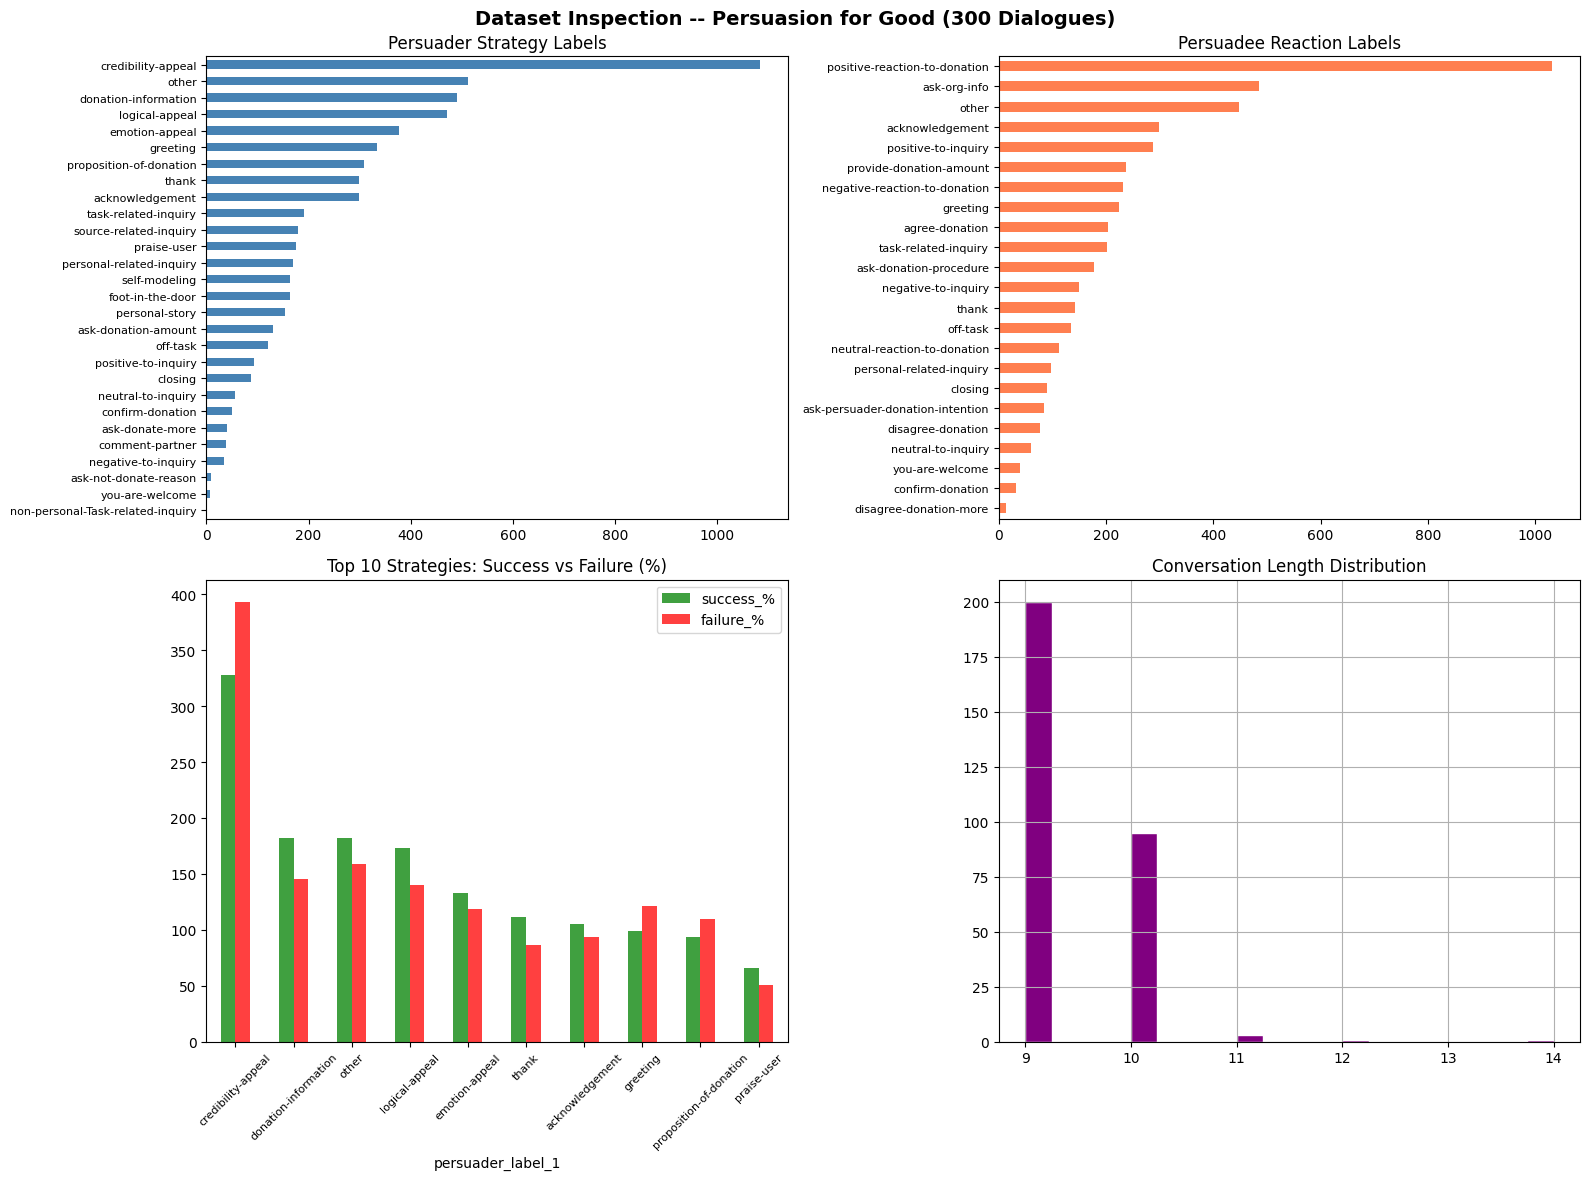

dataset_inspection.png


In [3]:
import matplotlib.pyplot as plt

total_dialogues  = df_dialog['dialogue_id'].nunique()
total_utterances = len(df_dialog)
avg_turns        = df_dialog.groupby('dialogue_id')['turn'].max().mean()
print(f"Dialogues: {total_dialogues} | Utterances: {total_utterances} | Avg turns: {avg_turns:.1f}")

turns_per_dialogue = df_dialog.groupby('dialogue_id')['turn'].max().reset_index()
turns_per_dialogue.columns = ['dialogue_id', 'max_turn']

er_labels = pd.concat([df_dialog['persuader_label_1'].dropna(), df_dialog['persuader_label_2'].dropna()])
er_counts = er_labels.value_counts()
ee_labels = pd.concat([df_dialog['persuadee_label_1'].dropna(), df_dialog['persuadee_label_2'].dropna()])
ee_counts = ee_labels.value_counts()

outcome_map = persuadee_info.set_index('dialogue_id')['donated'].to_dict()
df_dialog['donated'] = df_dialog['dialogue_id'].map(outcome_map)
persuader_rows = df_dialog[df_dialog['role']==0].dropna(subset=['persuader_label_1'])
success = persuader_rows[persuader_rows['donated']==1]['persuader_label_1'].value_counts()
failure = persuader_rows[persuader_rows['donated']==0]['persuader_label_1'].value_counts()
compare = pd.DataFrame({'success':success,'failure':failure}).fillna(0).astype(int)
compare['success_%'] = (compare['success']/donated*100).round(1)
compare['failure_%'] = (compare['failure']/not_donated*100).round(1)
compare = compare.sort_values('success_%', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Dataset Inspection -- Persuasion for Good (300 Dialogues)", fontsize=14, fontweight='bold')
er_counts.plot(kind='barh', ax=axes[0,0], color='steelblue'); axes[0,0].set_title("Persuader Strategy Labels"); axes[0,0].invert_yaxis(); axes[0,0].tick_params(axis='y', labelsize=8)
ee_counts.plot(kind='barh', ax=axes[0,1], color='coral'); axes[0,1].set_title("Persuadee Reaction Labels"); axes[0,1].invert_yaxis(); axes[0,1].tick_params(axis='y', labelsize=8)
compare.head(10)[['success_%','failure_%']].plot(kind='bar', ax=axes[1,0], color=['green','red'], alpha=0.75); axes[1,0].set_title("Top 10 Strategies: Success vs Failure (%)"); axes[1,0].tick_params(axis='x', rotation=45, labelsize=8)
turns_per_dialogue['max_turn'].hist(bins=20, ax=axes[1,1], color='purple', edgecolor='white'); axes[1,1].set_title("Conversation Length Distribution")
plt.tight_layout(); plt.savefig("dataset_inspection.png", dpi=150, bbox_inches='tight'); plt.show()
print("dataset_inspection.png")


In [4]:
PERSUASION_STRATEGIES = {'logical-appeal','emotion-appeal','credibility-appeal','foot-in-the-door','self-modeling','personal-story','donation-information','proposition-of-donation','ask-donate-more','personal-related-inquiry','task-related-inquiry','source-related-inquiry','confirm-donation','ask-donation-amount'}
POSITIVE_STRATEGIES = {'personal-story','donation-information','confirm-donation','positive-to-inquiry','self-modeling','logical-appeal','emotion-appeal','praise-user'}
NEGATIVE_STRATEGIES = {'ask-donate-more','neutral-to-inquiry','ask-not-donate-reason'}
POSITIVE_REACTIONS = {'agree-donation','positive-reaction-to-donation','provide-donation-amount','confirm-donation','ask-donation-procedure','ask-org-info'}
NEGATIVE_REACTIONS = {'disagree-donation','negative-reaction-to-donation','disagree-donation-more'}

def build_dialogue_summary(dialogue_id, df_dialog, persuadee_info):
    dlg = df_dialog[df_dialog['dialogue_id']==dialogue_id].copy()
    info_row = persuadee_info[persuadee_info['dialogue_id']==dialogue_id]
    if info_row.empty: return None
    info = info_row.iloc[0]
    donated_flag = int(info['donated']); actual_amount = float(info['actual_donation'])
    num_turns = int(info['num_turns']) if not pd.isna(info['num_turns']) else 0
    persuader_rows = dlg[dlg['role']==0]
    strategies_used = {}
    for col in ['persuader_label_1','persuader_label_2']:
        for label in persuader_rows[col].dropna():
            if label in PERSUASION_STRATEGIES: strategies_used[label] = strategies_used.get(label,0)+1
    positive_used = {k:v for k,v in strategies_used.items() if k in POSITIVE_STRATEGIES}
    negative_used = {k:v for k,v in strategies_used.items() if k in NEGATIVE_STRATEGIES}
    persuadee_rows = dlg[dlg['role']==1]; reactions = {}
    for label in persuadee_rows['persuadee_label_1'].dropna(): reactions[label] = reactions.get(label,0)+1
    positive_reactions = {k:v for k,v in reactions.items() if k in POSITIVE_REACTIONS}
    negative_reactions = {k:v for k,v in reactions.items() if k in NEGATIVE_REACTIONS}
    persuader_sentiment = persuader_rows['sentiment_pos'].mean()
    persuadee_labels_seq = persuadee_rows['persuadee_label_1'].dropna().tolist()
    had_initial_resistance = any(r in NEGATIVE_REACTIONS for r in persuadee_labels_seq[:3])
    eventual_agreement = 'agree-donation' in persuadee_labels_seq
    conversation_lines = []
    for _, row in dlg.iterrows():
        speaker = "Persuader" if row['role']==0 else "Persuadee"
        conversation_lines.append(f"{speaker}: {row['utterance']}")
    return {'dialogue_id':dialogue_id,'donated':donated_flag,'actual_amount':actual_amount,'num_turns':num_turns,'conversation_text':"\n".join(conversation_lines),'strategies_used':strategies_used,'positive_strategies':positive_used,'negative_strategies':negative_used,'reactions':reactions,'positive_reactions':positive_reactions,'negative_reactions':negative_reactions,'persuader_sentiment':round(persuader_sentiment,3),'had_initial_resistance':had_initial_resistance,'eventual_agreement':eventual_agreement}

def generate_coaching_feedback(s):
    amount_str = f"${s['actual_amount']:.2f}" if s['donated'] else "nothing"
    if s['donated']:
        if s['had_initial_resistance'] and s['eventual_agreement']:
            overall = f"This was a successful persuasion conversation -- the persuadee donated {amount_str}. Notably, the persuadee showed initial resistance but was eventually convinced, reflecting effective adaptive persuasion."
        else:
            overall = f"This was a successful persuasion conversation -- the persuadee donated {amount_str}. The persuader maintained a positive tone throughout and guided the persuadee toward a donation decision effectively."
    else:
        overall = "This persuasion conversation was unsuccessful -- the persuadee did not donate. While the persuader made genuine efforts, the approach had gaps that prevented the persuadee from committing."
    strengths = []
    if 'personal-story' in s['positive_strategies']: strengths.append("Used personal storytelling effectively -- sharing personal narratives builds emotional connection and increases donation likelihood.")
    if 'logical-appeal' in s['positive_strategies']: strengths.append("Incorporated logical arguments and factual information about the cause, helping persuadees who prefer evidence-based reasoning.")
    if 'emotion-appeal' in s['positive_strategies']: strengths.append("Made emotional appeals to highlight the impact on children, one of the most effective charity persuasion strategies.")
    if 'credibility-appeal' in s['strategies_used']: strengths.append("Established credibility by providing factual information about Save the Children's mission and track record.")
    if 'donation-information' in s['positive_strategies']: strengths.append("Clearly explained the donation procedure, reducing friction and increasing the persuadee's confidence.")
    if 'self-modeling' in s['positive_strategies']: strengths.append("Used self-modeling by expressing personal donation intent, creating social proof.")
    if s['positive_reactions']: strengths.append(f"Elicited positive responses including: {', '.join(s['positive_reactions'].keys())}.")
    if s['persuader_sentiment'] > 0.3: strengths.append(f"Maintained a positive conversational tone (avg positivity: {s['persuader_sentiment']:.2f}).")
    if not strengths: strengths.append("The persuader engaged with the persuadee and attempted to initiate a conversation about the cause.")
    weaknesses = []
    if 'ask-donate-more' in s['negative_strategies']: weaknesses.append("Pushed for a larger donation after initial agreement -- this risks reversing commitment.")
    if not s['donated'] and 'personal-story' not in s['strategies_used']: weaknesses.append("Did not use personal storytelling -- conversations without personal narratives show lower donation rates.")
    if not s['donated'] and 'emotion-appeal' not in s['strategies_used']: weaknesses.append("Lacked emotional appeal -- purely informational approaches are less effective.")
    if s['negative_reactions']: weaknesses.append(f"Persuadee showed resistance signals ({', '.join(s['negative_reactions'].keys())}) that were not adequately addressed.")
    if 'neutral-to-inquiry' in s['negative_strategies']: weaknesses.append("Gave neutral responses to questions, weakening credibility.")
    if not weaknesses: weaknesses.append("No major weaknesses identified." if s['donated'] else "The persuader did not adapt strategy when the persuadee showed disengagement.")
    suggestions = []
    if not s['donated']:
        if 'personal-story' not in s['strategies_used']: suggestions.append("1. Open with a brief personal story before making any donation request.")
        if 'foot-in-the-door' not in s['strategies_used']: suggestions.append("2. Use foot-in-the-door -- start with a very small ask (e.g. $0.10) before working up.")
        if 'self-modeling' not in s['strategies_used']: suggestions.append("3. Mention your own intention to donate to create social proof.")
        suggestions.append("4. When persuadee resists, switch strategy -- do not repeat the same approach.")
        suggestions.append("5. End with a concrete low-barrier ask: 'Even $0.25 makes a real difference today.'")
    else:
        suggestions.append("1. This conversation is a model. Key elements: " + (', '.join(s['positive_strategies'].keys()) if s['positive_strategies'] else 'consistent engagement') + ".")
        suggestions.append("2. Document which turn led to agreement and replicate that approach.")
        if 'ask-donate-more' in s['negative_strategies']: suggestions.append("3. Avoid pushing for more after agreement.")
    return f"OVERALL PERFORMANCE:\n{overall}\n\nWHAT WORKED:\n" + "\n".join(f"- {x}" for x in strengths) + "\n\nAREAS FOR IMPROVEMENT:\n" + "\n".join(f"- {w}" for w in weaknesses) + "\n\nSPECIFIC SUGGESTIONS:\n" + "\n".join(suggestions)

all_summaries = []
for did in df_dialog['dialogue_id'].unique():
    s = build_dialogue_summary(did, df_dialog, persuadee_info)
    if s: all_summaries.append(s)

coaching_pairs = []
for s in all_summaries:
    coaching_pairs.append({'dialogue_id':s['dialogue_id'],'donated':s['donated'],'actual_amount':s['actual_amount'],'conversation_text':s['conversation_text'],'coaching_feedback':generate_coaching_feedback(s)})

df_coaching = pd.DataFrame(coaching_pairs)
df_coaching.to_csv("coaching_pairs.csv", index=False)
print(f"Generated {len(df_coaching)} coaching pairs | Success: {df_coaching['donated'].sum()} | Failed: {(df_coaching['donated']==0).sum()}")


Generated 300 coaching pairs | Success: 148 | Failed: 152


In [5]:
import json
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df_coaching, test_size=0.30, random_state=42, stratify=df_coaching['donated'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['donated'])

assert len(set(train_df['dialogue_id']) & set(val_df['dialogue_id'])) == 0
assert len(set(train_df['dialogue_id']) & set(test_df['dialogue_id'])) == 0
assert len(set(val_df['dialogue_id']) & set(test_df['dialogue_id'])) == 0

train_df.to_csv("train_coaching.csv", index=False)
val_df.to_csv("val_coaching.csv", index=False)
test_df.to_csv("test_coaching.csv", index=False)
with open("test_ids_locked.json","w") as f: json.dump(test_df['dialogue_id'].tolist(), f)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print("Zero leakage")
for name, df in [("TRAIN",train_df),("VAL",val_df),("TEST",test_df)]:
    d = df['donated'].sum()
    print(f"  {name}: donated={d} ({d/len(df)*100:.0f}%) | not={len(df)-d}")


Train: 210 | Val: 45 | Test: 45
Zero leakage
  TRAIN: donated=104 (50%) | not=106
  VAL: donated=22 (49%) | not=23
  TEST: donated=22 (49%) | not=23


In [6]:
import json, numpy as np
from datasets import Dataset

train_df = pd.read_csv("train_coaching.csv")
val_df = pd.read_csv("val_coaching.csv")

SYSTEM_PROMPT = "You are an expert communication coach specializing in charitable persuasion conversations. Your role is to analyze a conversation between a persuader and a persuadee, where the persuader is trying to convince the persuadee to donate to Save the Children charity.\n\nProvide structured coaching feedback to the persuader covering:\n1. Overall performance assessment\n2. What communication strategies worked well\n3. Areas that need improvement\n4. Specific actionable suggestions for future conversations\n\nBe specific, reference the actual conversation, and focus on persuasion effectiveness."

def format_example(row):
    return {"messages": [
        {"role":"system","content":SYSTEM_PROMPT},
        {"role":"user","content":f"Analyze the following persuasion conversation and provide detailed coaching feedback for the persuader:\n\n--- CONVERSATION START ---\n{row['conversation_text']}\n--- CONVERSATION END ---\n\nProvide your coaching feedback now."},
        {"role":"assistant","content":row['coaching_feedback']},
    ]}

train_formatted = [format_example(row) for _, row in train_df.iterrows()]
val_formatted = [format_example(row) for _, row in val_df.iterrows()]

estimates = [int(len(" ".join([m['content'] for m in ex['messages']]).split())*1.3) for ex in train_formatted]
print(f"Token estimates -- Min:{min(estimates)} Max:{max(estimates)} Mean:{np.mean(estimates):.0f}")

train_dataset = Dataset.from_list(train_formatted)
val_dataset = Dataset.from_list(val_formatted)
train_dataset.save_to_disk("train_dataset")
val_dataset.save_to_disk("val_dataset")
with open("train_formatted.json","w") as f: json.dump(train_formatted, f)
with open("val_formatted.json","w") as f: json.dump(val_formatted, f)

print(f"Saved: train={len(train_dataset)} val={len(val_dataset)}")



Token estimates -- Min:449 Max:2021 Mean:837


Saving the dataset (0/1 shards):   0%|          | 0/210 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/45 [00:00<?, ? examples/s]

Saved: train=210 val=45


In [1]:


import unsloth
from unsloth import FastLanguageModel
from unsloth.chat_templates import get_chat_template
import torch, gc, json, time
from datasets import load_from_disk, Dataset
from trl import SFTTrainer, SFTConfig

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# Load datasets
try:
    train_dataset = load_from_disk("train_dataset")
    val_dataset = load_from_disk("val_dataset")
except:
    with open("train_formatted.json") as f: train_dataset = Dataset.from_list(json.load(f))
    with open("val_formatted.json") as f: val_dataset = Dataset.from_list(json.load(f))
print(f"Datasets: train={len(train_dataset)} val={len(val_dataset)}")

MODEL_NAME = "Qwen/Qwen3.5-4B-Base"
MAX_SEQ_LENGTH = 2048
LORA_RANK = 16

print(f"\nLoading {MODEL_NAME}...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME, max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True, dtype=None, trust_remote_code=True)
print(f"Base model loaded -- GPU: {torch.cuda.memory_allocated()/1e9:.2f} GB")

model = FastLanguageModel.get_peft_model(model,
    r=LORA_RANK, target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
    lora_alpha=32, lora_dropout=0.05, bias="none",
    use_gradient_checkpointing="unsloth", random_state=42)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"LoRA attached -- trainable: {trainable:,} ({trainable/total*100:.2f}%)")

# Apply chat template
tokenizer = get_chat_template(tokenizer, chat_template="qwen-2.5")
def apply_template(examples):
    texts = [tokenizer.apply_chat_template(ex, tokenize=False, add_generation_prompt=False) for ex in examples["messages"]]
    return {"text": texts}
train_dataset = train_dataset.map(apply_template, batched=True)
val_dataset = val_dataset.map(apply_template, batched=True)
print(f"Chat template applied")


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
GPU: NVIDIA L4
GPU memory: 23.7 GB
Datasets: train=210 val=45

Loading Qwen/Qwen3.5-4B-Base...
Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2026.3.17: Fast Qwen3_5 patching. Transformers: 5.3.0.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Qwen3_5 does not support SDPA - switching to fast eager.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

...

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


Unsloth: Making `model.base_model.model.model.language_model` require gradients
LoRA attached -- trainable: 21,233,664 (0.81%)


Map:   0%|          | 0/210 [00:00<?, ? examples/s]

Map:   0%|          | 0/45 [00:00<?, ? examples/s]

Chat template applied


In [3]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [1]:
import unsloth
from unsloth import FastLanguageModel
from unsloth.chat_templates import get_chat_template
import torch, gc, json, time
from datasets import load_from_disk, Dataset
from trl import SFTTrainer, SFTConfig

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

try:
    train_dataset = load_from_disk("train_dataset")
    val_dataset = load_from_disk("val_dataset")
except:
    with open("train_formatted.json") as f:
        train_dataset = Dataset.from_list(json.load(f))
    with open("val_formatted.json") as f:
        val_dataset = Dataset.from_list(json.load(f))

print(f"Datasets: train={len(train_dataset)} val={len(val_dataset)}")

MODEL_NAME = "Qwen/Qwen3.5-4B-Base"
MAX_SEQ_LENGTH = 1024     # start here; if still OOM, use 768
LORA_RANK = 8             # reduce from 16

print(f"\nLoading {MODEL_NAME}...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True,
    dtype=None,
    trust_remote_code=True,
)

print(f"Base model loaded -- GPU: {torch.cuda.memory_allocated()/1e9:.2f} GB")

model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_RANK,
    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
)

tokenizer = get_chat_template(tokenizer, chat_template="qwen-2.5")

def apply_template(examples):
    texts = [
        tokenizer.apply_chat_template(ex, tokenize=False, add_generation_prompt=False)
        for ex in examples["messages"]
    ]
    return {"text": texts}

train_dataset = train_dataset.map(apply_template, batched=True)
val_dataset = val_dataset.map(apply_template, batched=True)

training_args = SFTConfig(
    output_dir="qwen_coaching_lora",
    num_train_epochs=3,
    per_device_train_batch_size=1,      # reduced from 4
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,      # keep effective batch via accumulation
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    optim="adamw_8bit",
    gradient_checkpointing=True,
    max_seq_length=MAX_SEQ_LENGTH,
    dataset_text_field="text",
    packing=False,                      # safer first run
    eval_strategy="no",                 # disable eval first to avoid spikes
    save_strategy="epoch",
    save_total_limit=2,
    logging_steps=10,
    report_to="none",
    seed=42,
)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    args=training_args,
)

print("\nStarting training...")
trainer_stats = trainer.train()

model.save_pretrained("qwen_coaching_lora_final")
tokenizer.save_pretrained("qwen_coaching_lora_final")
print("LoRA adapters saved.")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
GPU: NVIDIA L4
GPU memory: 23.7 GB
Datasets: train=210 val=45

Loading Qwen/Qwen3.5-4B-Base...
Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2026.3.17: Fast Qwen3_5 patching. Transformers: 5.3.0.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Unsloth: Qwen3_5 does not support SDPA - switching to fast eager.


Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

Qwen/Qwen3.5-4B-Base does not have a padding token! Will use pad_token = <|vision_pad|>.
Base model loaded -- GPU: 3.34 GB


...

Unsloth: Tokenizing ["text"] (num_proc=12):   0%|          | 0/45 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248044}.



Starting training...
Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
10,13.193044
20,9.492062
30,7.679811
40,8.038074
50,8.111583
60,7.283589
70,7.456422
80,7.556712


LoRA adapters saved.


In [3]:
print(type(tokenizer))
chat_tokenizer = tokenizer.tokenizer if hasattr(tokenizer, "tokenizer") else tokenizer
print(type(chat_tokenizer))

sample_msgs = [
    {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT}]},
    {"role": "user", "content": [{"type": "text", "text": "test conversation"}]},
]

sample_prompt = chat_tokenizer.apply_chat_template(
    sample_msgs,
    tokenize=False,
    add_generation_prompt=True
)

print(sample_prompt[:500])

<class 'transformers.models.qwen3_vl.processing_qwen3_vl.Qwen3VLProcessor'>
<class 'transformers.tokenization_utils_tokenizers.TokenizersBackend'>
<|im_start|>system
You are an expert communication coach specializing in charitable persuasion conversations. Your role is to analyze a conversation between a persuader and a persuadee, where the persuader is trying to convince the persuadee to donate to Save the Children charity.

Provide structured coaching feedback to the persuader covering:
1. Overall performance assessment
2. What communication strategies worked well
3. Areas that need improvement
4. Specific actionable suggestions for futu


In [ ]:
import pandas as pd
import torch, gc, time

FastLanguageModel.for_inference(model)

test_df = pd.read_csv("test_coaching.csv")

SYSTEM_PROMPT = """You are an expert communication coach specializing in charitable persuasion conversations.
Your role is to analyze a conversation between a persuader and a persuadee, where the persuader is trying to convince the persuadee to donate to Save the Children charity.

Provide structured coaching feedback to the persuader covering:
1. Overall performance assessment
2. What communication strategies worked well
3. Areas that need improvement
4. Specific actionable suggestions for future conversations

Be specific, reference the actual conversation, and focus on persuasion effectiveness."""

def build_prompt(conv_text):
    return f"""Analyze the following persuasion conversation and provide detailed coaching feedback for the persuader:

--- CONVERSATION START ---
{conv_text}
--- CONVERSATION END ---

Provide your coaching feedback now."""

# unwrap tokenizer if needed
chat_tokenizer = tokenizer.tokenizer if hasattr(tokenizer, "tokenizer") else tokenizer

finetuned_results, failed_ids = [], []

for i, (_, row) in enumerate(test_df.iterrows()):
    t0 = time.time()
    try:
        conv_text = "" if pd.isna(row["conversation_text"]) else str(row["conversation_text"])

        msgs = [
            {
                "role": "system",
                "content": [{"type": "text", "text": SYSTEM_PROMPT}],
            },
            {
                "role": "user",
                "content": [{"type": "text", "text": build_prompt(conv_text)}],
            },
        ]

        prompt_text = chat_tokenizer.apply_chat_template(
            msgs,
            tokenize=False,
            add_generation_prompt=True,
        )

        inputs = chat_tokenizer(prompt_text, return_tensors="pt").to(model.device)

        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=512,
                temperature=0.3,
                do_sample=True,
                top_p=0.9,
                repetition_penalty=1.1,
                pad_token_id=chat_tokenizer.eos_token_id,
            )

        input_len = inputs["input_ids"].shape[1]
        resp = chat_tokenizer.decode(out[0][input_len:], skip_special_tokens=True)

        finetuned_results.append({
            "dialogue_id": row["dialogue_id"],
            "donated": row["donated"],
            "actual_amount": row["actual_amount"],
            "conversation_text": conv_text,
            "reference_feedback": row["coaching_feedback"],
            "finetuned_feedback": resp,
            "input_tokens": int(input_len),
            "output_word_count": len(resp.split()),
            "inference_time_s": round(time.time() - t0, 2),
        })

        print(f"[{i+1:02d}/{len(test_df)}] OK")

    except Exception as e:
        failed_ids.append(row.get("dialogue_id", f"row_{i}"))
        print(f"[{i+1:02d}/{len(test_df)}] FAILED -- {repr(e)}")

    if (i + 1) % 10 == 0:
        torch.cuda.empty_cache()
        gc.collect()

df_finetuned = pd.DataFrame(finetuned_results)
df_finetuned.to_csv("finetuned_outputs.csv", index=False)

print(f"\nSaved finetuned_outputs.csv -- {len(df_finetuned)} rows, {len(failed_ids)} failed")

[01/45] OK
[02/45] OK
[03/45] OK
[04/45] OK
[05/45] OK
[06/45] OK
[07/45] OK
[08/45] OK
[09/45] OK
[10/45] OK
[11/45] OK
[12/45] OK
[13/45] OK
[14/45] OK
[15/45] OK
[16/45] OK
[17/45] OK
[18/45] OK
[19/45] OK
[20/45] OK
[21/45] OK
[22/45] OK
[23/45] OK
[24/45] OK
[25/45] OK
[26/45] OK
[27/45] OK
[28/45] OK
[29/45] OK
[30/45] OK
[31/45] OK
[32/45] OK
[33/45] OK
[34/45] OK
[35/45] OK
[36/45] OK
[37/45] OK
[38/45] OK
[39/45] OK
[40/45] OK
[41/45] OK
[42/45] OK
[43/45] OK
[44/45] OK


In [1]:

import numpy as np, re
from rouge_score import rouge_scorer
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

scorer = rouge_scorer.RougeScorer(['rouge1','rouge2','rougeL'], use_stemmer=True)

df_baseline = pd.read_csv("baseline_outputs.csv")
df_finetuned = pd.read_csv("finetuned_outputs.csv")

baseline_map = dict(zip(df_baseline['dialogue_id'], df_baseline['baseline_feedback']))
finetuned_map = dict(zip(df_finetuned['dialogue_id'], df_finetuned['finetuned_feedback']))
reference_map = dict(zip(df_finetuned['dialogue_id'], df_finetuned['reference_feedback']))

common_ids = sorted(set(baseline_map.keys()) & set(finetuned_map.keys()))
print(f"Common test conversations: {len(common_ids)}")

references = [reference_map[did] for did in common_ids]
baselines = [baseline_map[did] for did in common_ids]
finetuneds = [finetuned_map[did] for did in common_ids]

def compute_rouge(preds, refs):
    r1,r2,rL = [],[],[]
    for p,r in zip(preds,refs):
        scores = scorer.score(r,p)
        r1.append(scores['rouge1'].fmeasure); r2.append(scores['rouge2'].fmeasure); rL.append(scores['rougeL'].fmeasure)
    return {'rouge1':round(np.mean(r1),4),'rouge2':round(np.mean(r2),4),'rougeL':round(np.mean(rL),4)}

rouge_baseline = compute_rouge(baselines, references)
rouge_finetuned = compute_rouge(finetuneds, references)

print(f"\n{'Metric':<12} {'9B Instruct':>12} {'4B Fine-tuned':>14} {'Delta':>10}")
print("-"*50)
for m in ['rouge1','rouge2','rougeL']:
    b,f = rouge_baseline[m], rouge_finetuned[m]
    d = f-b; arrow = "up" if d>0 else "dn"
    print(f"{m:<12} {b:>12.4f} {f:>14.4f} {d:>+9.4f} {arrow}")

# Content quality
def quality_metrics(feedbacks, label):
    has_overall = sum(1 for fb in feedbacks if any(kw in fb.lower() for kw in ['overall','performance','assessment']))
    has_strengths = sum(1 for fb in feedbacks if any(kw in fb.lower() for kw in ['worked','strength','effective']))
    has_weaknesses = sum(1 for fb in feedbacks if any(kw in fb.lower() for kw in ['improv','weakness','didn']))
    has_suggestions = sum(1 for fb in feedbacks if any(kw in fb.lower() for kw in ['suggest','recommend','try','consider']))
    n = len(feedbacks)
    return {label: {'overall':round(has_overall/n*100,1),'strengths':round(has_strengths/n*100,1),'weaknesses':round(has_weaknesses/n*100,1),'suggestions':round(has_suggestions/n*100,1),'avg_words':round(np.mean([len(fb.split()) for fb in feedbacks]),1)}}

q_b = quality_metrics(baselines, "9B Instruct")
q_f = quality_metrics(finetuneds, "4B Fine-tuned")

print(f"\n{'Metric':<22} {'9B Instruct':>12} {'4B Fine-tuned':>14}")
print("-"*50)
for key in ['overall','strengths','weaknesses','suggestions','avg_words']:
    bv = q_b['9B Instruct'][key]; fv = q_f['4B Fine-tuned'][key]
    print(f"{key+'_%' if key!='avg_words' else key:<22} {bv:>12} {fv:>14}")


NameError: name 'pd' is not defined

In [ ]:
# ============================================================
# CELL 13 — Comparison Visualizations (CPU)
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("9B Instruct (Baseline) vs 4B Fine-tuned -- Evaluation", fontsize=14, fontweight='bold')

# ROUGE scores
metrics_names = ['ROUGE-1','ROUGE-2','ROUGE-L']
bv = [rouge_baseline['rouge1'],rouge_baseline['rouge2'],rouge_baseline['rougeL']]
fv = [rouge_finetuned['rouge1'],rouge_finetuned['rouge2'],rouge_finetuned['rougeL']]
x = np.arange(len(metrics_names)); w = 0.35
axes[0,0].bar(x-w/2,bv,w,label='9B Instruct',color='steelblue',alpha=0.8)
axes[0,0].bar(x+w/2,fv,w,label='4B Fine-tuned',color='coral',alpha=0.8)
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(metrics_names)
axes[0,0].set_title('ROUGE Scores'); axes[0,0].legend()

# Structure coverage
struct_keys = ['overall','strengths','weaknesses','suggestions']
b_struct = [q_b['9B Instruct'][k] for k in struct_keys]
f_struct = [q_f['4B Fine-tuned'][k] for k in struct_keys]
x2 = np.arange(len(struct_keys))
axes[0,1].bar(x2-w/2,b_struct,w,label='9B Instruct',color='steelblue',alpha=0.8)
axes[0,1].bar(x2+w/2,f_struct,w,label='4B Fine-tuned',color='coral',alpha=0.8)
axes[0,1].set_xticks(x2); axes[0,1].set_xticklabels(struct_keys)
axes[0,1].set_title('Feedback Structure Coverage (%)'); axes[0,1].legend(); axes[0,1].set_ylim(0,110)

# Word count distributions
axes[1,0].hist([len(r.split()) for r in references],bins=15,alpha=0.5,label='Reference',color='green')
axes[1,0].hist([len(b.split()) for b in baselines],bins=15,alpha=0.5,label='9B Instruct',color='steelblue')
axes[1,0].hist([len(f.split()) for f in finetuneds],bins=15,alpha=0.5,label='4B Fine-tuned',color='coral')
axes[1,0].set_title('Output Length Distribution'); axes[1,0].legend()

# Per-conversation ROUGE-L scatter
per_b = [scorer.score(r,b)['rougeL'].fmeasure for r,b in zip(references,baselines)]
per_f = [scorer.score(r,f)['rougeL'].fmeasure for r,f in zip(references,finetuneds)]
axes[1,1].scatter(per_b,per_f,alpha=0.6,s=40,c='purple')
mx = max(max(per_b),max(per_f))+0.05
axes[1,1].plot([0,mx],[0,mx],'k--',alpha=0.3,label='y=x')
axes[1,1].set_xlabel('9B Instruct ROUGE-L'); axes[1,1].set_ylabel('4B Fine-tuned ROUGE-L')
axes[1,1].set_title('Per-Conversation ROUGE-L'); axes[1,1].legend()

plt.tight_layout()
plt.savefig("comparison_chart.png", dpi=150, bbox_inches='tight')
plt.show()
print("comparison_chart.png saved")

# Final summary
print("\n" + "="*60)
print("EXPERIMENT COMPLETE")
print("="*60)
print(f"Baseline : Qwen/Qwen3.5-9B (instruct, zero-shot)")
print(f"Fine-tuned: Qwen/Qwen3.5-4B-Base (QLoRA, rank {LORA_RANK})")
print(f"Test set  : {len(common_ids)} conversations")
for m in ['rouge1','rouge2','rougeL']:
    b,f = rouge_baseline[m], rouge_finetuned[m]
    winner = "4B-FT" if f>b else "9B-Inst" if b>f else "Tie"
    print(f"  {m}: {b:.4f} vs {f:.4f} -- winner: {winner}")
